## Step 1: Mount Drive + Install Dependencies

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

import os, glob, shutil, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
import torch

print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB')
print('Ready!')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU : Tesla T4
VRAM: 16 GB
Ready!


## Step 2: Set Paths + Verify DS1 Test Split Exists

In [ ]:
# Paths
TARGET_CLASSES = ['button', 'field', 'image', 'link', 'text']

V17_ROOT   = '/content/drive/MyDrive/DatasetNewV17'
DRIVE_SAVE = os.path.join(V17_ROOT, 'trained_models')
DS1_CLEAN  = os.path.join(V17_ROOT, 'ds1_clean')        # remapped DS1 labels
EVAL_OUT   = '/content/ui_v17_eval_ds1'                  # local eval output
os.makedirs(EVAL_OUT, exist_ok=True)

# Dataset test split folders
DS1_TEST_IMGS = os.path.join(DS1_CLEAN, 'test', 'images')
DS1_TEST_LBLS = os.path.join(DS1_CLEAN, 'test', 'labels')

assert os.path.exists(DS1_TEST_IMGS), f'DS1 test images not found: {DS1_TEST_IMGS}'
assert os.path.exists(DS1_TEST_LBLS), f'DS1 test labels not found: {DS1_TEST_LBLS}'

n_imgs = len([f for f in os.listdir(DS1_TEST_IMGS)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
n_lbls = len([f for f in os.listdir(DS1_TEST_LBLS) if f.endswith('.txt')])

print('DS1 test split found!')
print(f'  Images : {n_imgs}')
print(f'  Labels : {n_lbls}')
print(f'  Status : {"OK" if n_imgs == n_lbls else "MISMATCH — check labels!"}')

# Count annotations per class
ann_counter = Counter()
for lf in os.listdir(DS1_TEST_LBLS):
    if not lf.endswith('.txt'):
        continue
    with open(os.path.join(DS1_TEST_LBLS, lf)) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                ann_counter[int(float(parts[0]))] += 1

print('\nDS1 test annotation counts:')
print(f'  {"Class":10s}  {"Count":>8s}')
print('  ' + '-' * 22)
for i, cls in enumerate(TARGET_CLASSES):
    print(f'  {cls:10s}  {ann_counter.get(i, 0):>8,}')
print(f'  {"TOTAL":10s}  {sum(ann_counter.values()):>8,}')

DS1 test split found!
  Images : 242
  Labels : 242
  Status : OK

DS1 test annotation counts:
  Class          Count
  ----------------------
  button         2,872
  field            240
  image          2,000
  link           1,674
  text           3,870
  TOTAL         10,656


## Step 3: Build DS1-Only Evaluation YAML

In [ ]:
# Build a yaml that points ONLY to DS1 test images
# YOLO val reads the 'val' key — we point it at DS1 test

DS1_EVAL_YAML = '/content/ds1_test_eval.yaml'

ds1_cfg = {
    'path' : DS1_CLEAN,
    'train': os.path.join(DS1_CLEAN, 'train', 'images'),
    'val'  : DS1_TEST_IMGS,
    'test' : DS1_TEST_IMGS,
    'nc'   : len(TARGET_CLASSES),
    'names': TARGET_CLASSES,
}

with open(DS1_EVAL_YAML, 'w') as f:
    yaml.dump(ds1_cfg, f, default_flow_style=False)

print('DS1 eval YAML written to:', DS1_EVAL_YAML)
print()
with open(DS1_EVAL_YAML) as f:
    print(f.read())

DS1 eval YAML written to: /content/ds1_test_eval.yaml

names:
- button
- field
- image
- link
- text
nc: 5
path: /content/drive/MyDrive/DatasetNewV17/ds1_clean
test: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images
train: /content/drive/MyDrive/DatasetNewV17/ds1_clean/train/images
val: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images



## Step 4: Load the Trained V17 Model

In [ ]:
# Try models in priority order: BOOST > FINAL > main
BEST_MODEL_PATH = None
for pt_name in ['best_v17_BOOST.pt', 'best_v17_FINAL.pt', 'best_v17_main.pt']:
    p = os.path.join(DRIVE_SAVE, pt_name)
    if os.path.exists(p):
        BEST_MODEL_PATH = p
        break

# Fallback: search /content for any best.pt
if BEST_MODEL_PATH is None:
    found = sorted(glob.glob('/content/**/best.pt', recursive=True),
                   key=os.path.getmtime)
    if found:
        BEST_MODEL_PATH = found[-1]

assert BEST_MODEL_PATH is not None, 'No trained model found! Check DRIVE_SAVE path.'

model = YOLO(BEST_MODEL_PATH)
print(f'Model loaded : {BEST_MODEL_PATH}')
print(f'Model classes: {model.names}')
print(f'Target classes: {TARGET_CLASSES}')

Model loaded : /content/drive/MyDrive/DatasetNewV17/trained_models/best_v17_FINAL.pt
Model classes: {0: 'button', 1: 'field', 2: 'image', 3: 'link', 4: 'text'}
Target classes: ['button', 'field', 'image', 'link', 'text']


## Step 5: Run Evaluation on DS1 Test Split

> This is the main benchmarking cell — all metrics are computed here on DS1 test only.

In [ ]:
print('Running YOLO evaluation on DS1 test split...')
print('=' * 55)

val_results = model.val(
    data     = DS1_EVAL_YAML,
    split    = 'val',
    imgsz    = 800,
    batch    = 16,
    conf     = 0.001,
    iou      = 0.6,
    plots    = True,
    save_dir = EVAL_OUT,
    verbose  = True,
)

print('\nEvaluation complete!')

Running YOLO evaluation on DS1 test split...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 61.5±132.9 ms, read: 1.9±3.8 MB/s, size: 115.2 KB)
val: Scanning /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/labels.cache... 242 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 242/242 29.9Mit/s 0.0s
val: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images/ds1_androidpolice_com_png.rf.318e9d0fcc5beef7f5e48edadf1a4ab5.jpg: 2 duplicate labels removed
val: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images/ds1_androidpolice_com_png.rf.DNFprvYfS9plXdAH4KMm.jpg: 2 duplicate labels removed
val: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images/ds1_bbc_com_png.rf.01759781597857d451c44c7560e4e0bb.jpg: 1 duplicate labels removed
val: /content/drive/MyDrive/DatasetNewV17/ds1_clean/test/images/ds1_bbc_com_png.rf.XXZRInSc1rB

## Step 6: Print Full Results Summary

In [ ]:
# Extract metrics
mAP50    = float(val_results.box.map50)
mAP5095  = float(val_results.box.map)
prec     = float(val_results.box.mp)
rec      = float(val_results.box.mr)
f1_score = 2 * prec * rec / (prec + rec + 1e-9)

# Per-class AP@50
per_class_ap50 = [float(val_results.box.ap50[i])
                  for i in range(len(TARGET_CLASSES))]

# Per-class AP@50:95  ← NEW
per_class_ap5095 = [float(val_results.box.ap[i])
                    for i in range(len(TARGET_CLASSES))]

# Per-class P and R
try:
    per_class_p = [float(val_results.box.p[i]) for i in range(len(TARGET_CLASSES))]
    per_class_r = [float(val_results.box.r[i]) for i in range(len(TARGET_CLASSES))]
except Exception:
    per_class_p = [None] * len(TARGET_CLASSES)
    per_class_r = [None] * len(TARGET_CLASSES)

# ── Overall summary ────────────────────────────────────────────────────────────
print('=' * 60)
print('  ExpliUI V17 — DS1 TEST SPLIT RESULTS')
print('=' * 60)
print(f'  mAP@0.5        : {mAP50:.4f}  ({mAP50*100:.2f}%)')
print(f'  mAP@0.5:0.95   : {mAP5095:.4f}  ({mAP5095*100:.2f}%)')
print(f'  Precision      : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall         : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1 Score       : {f1_score:.4f}  ({f1_score*100:.2f}%)')
print(f'  Test images    : {n_imgs}')
print(f'  Model          : {os.path.basename(BEST_MODEL_PATH)}')

# Per-class table (AP@50 + AP@50:95 + P + R + F1)
print('\n' + '=' * 75)
print('  PER-CLASS RESULTS (DS1 test split)')
print('=' * 75)
header = f'  {"Class":10s}  {"AP@50":>8s}  {"AP@50:95":>10s}  {"Precision":>10s}  {"Recall":>8s}  {"F1":>6s}'
print(header)
print('  ' + '-' * (len(header) - 2))

rows = []
for i, cls in enumerate(TARGET_CLASSES):
    ap    = per_class_ap50[i]
    ap95  = per_class_ap5095[i]
    p     = per_class_p[i]
    r     = per_class_r[i]
    f1_c  = (2 * p * r / (p + r + 1e-9)) if (p is not None and r is not None) else None
    p_str   = f'{p:.4f}'   if p    is not None else 'N/A'
    r_str   = f'{r:.4f}'   if r    is not None else 'N/A'
    f1_str  = f'{f1_c:.4f}' if f1_c is not None else 'N/A'
    print(f'  {cls:10s}  {ap:8.4f}  {ap95:10.4f}  {p_str:>10s}  {r_str:>8s}  {f1_str:>6s}')
    rows.append({
        'Class'     : cls,
        'AP@50'     : round(ap,   4),
        'AP@50:95'  : round(ap95, 4),
        'Precision' : round(p,    4) if p    is not None else None,
        'Recall'    : round(r,    4) if r    is not None else None,
        'F1'        : round(f1_c, 4) if f1_c is not None else None,
    })

print('  ' + '-' * (len(header) - 2))
print(f'  {"MEAN":10s}  {mAP50:8.4f}  {mAP5095:10.4f}  {prec:>10.4f}  {rec:>8.4f}  {f1_score:>6.4f}')

# Save results as CSV
df = pd.DataFrame(rows)
df.loc[len(df)] = {
    'Class'     : 'MEAN',
    'AP@50'     : round(mAP50,   4),
    'AP@50:95'  : round(mAP5095, 4),
    'Precision' : round(prec,    4),
    'Recall'    : round(rec,     4),
    'F1'        : round(f1_score,4),
}
csv_path = os.path.join(EVAL_OUT, 'ds1_test_results.csv')
df.to_csv(csv_path, index=False)
print(f'\nResults saved to: {csv_path}')


  ExpliUI V17 — DS1 TEST SPLIT RESULTS
  mAP@0.5        : 0.5651  (56.51%)
  mAP@0.5:0.95   : 0.4039  (40.39%)
  Precision      : 0.6497  (64.97%)
  Recall         : 0.5400  (54.00%)
  F1 Score       : 0.5898  (58.98%)
  Test images    : 242
  Model          : best_v17_FINAL.pt

  PER-CLASS RESULTS (DS1 test split)
  Class          AP@50    AP@50:95   Precision    Recall      F1
  --------------------------------------------------------------
  button        0.5473      0.3775      0.5966    0.5206  0.5560
  field         0.7488      0.5900      0.7855    0.7521  0.7685
  image         0.4659      0.3168      0.6069    0.4252  0.5000
  link          0.6046      0.4585      0.7217    0.5228  0.6063
  text          0.4588      0.2767      0.5380    0.4795  0.5071
  --------------------------------------------------------------
  MEAN          0.5651      0.4039      0.6497    0.5400  0.5898

Results saved to: /content/ui_v17_eval_ds1/ds1_test_results.csv


## Step 7: Per-Class AP@50 and AP@50:95 Bar Charts

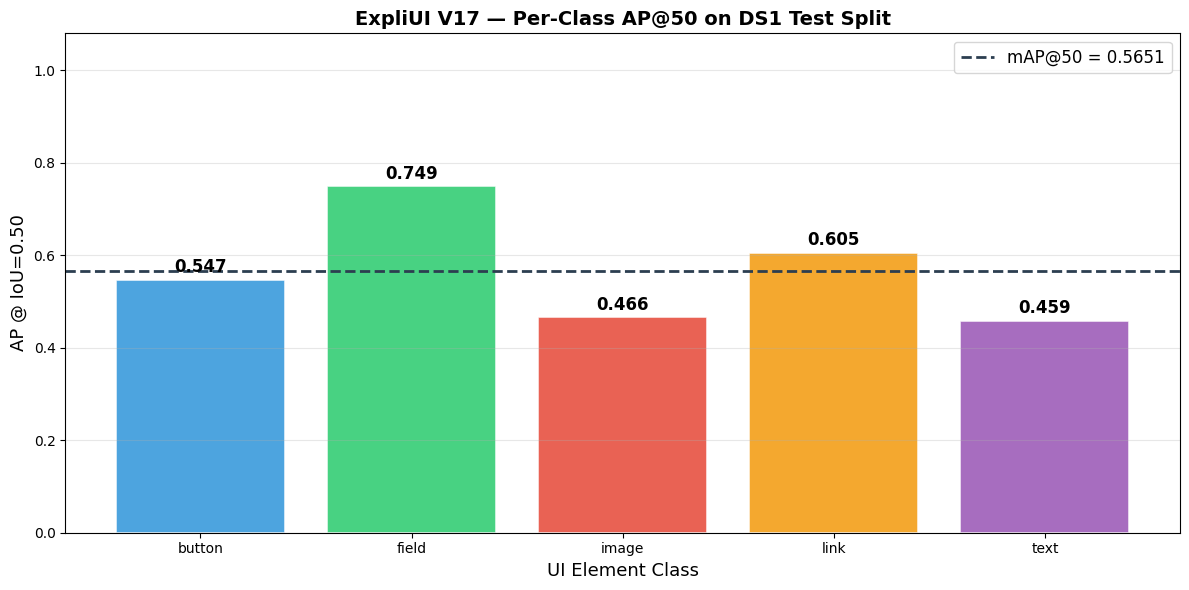

Saved: /content/ui_v17_eval_ds1/ds1_test_per_class_ap50.png


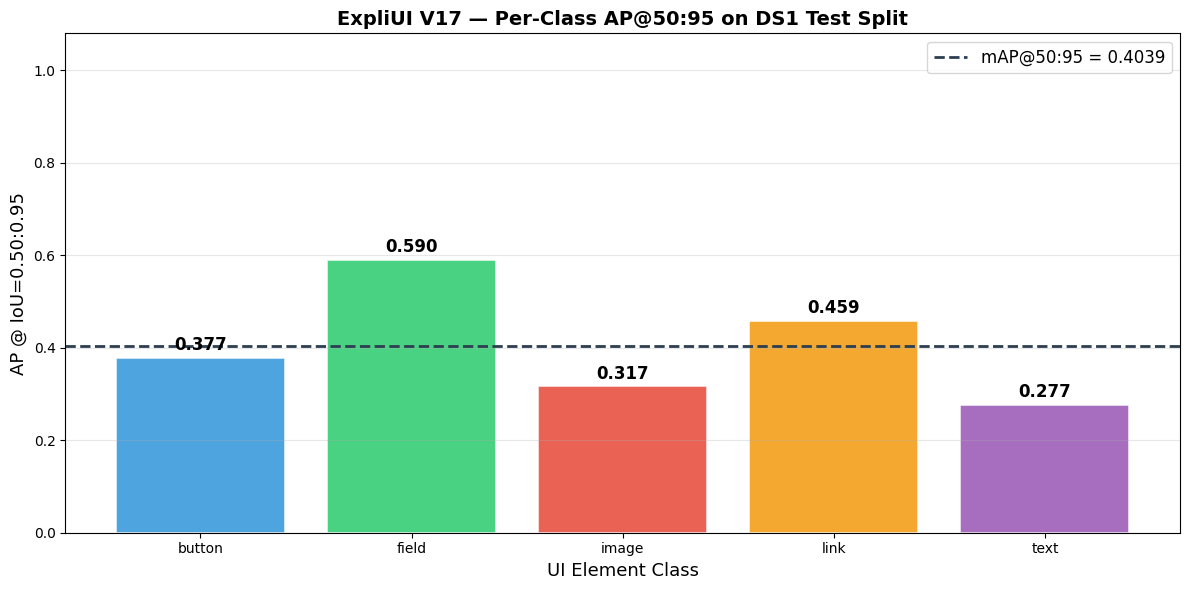

Saved: /content/ui_v17_eval_ds1/ds1_test_per_class_ap5095.png


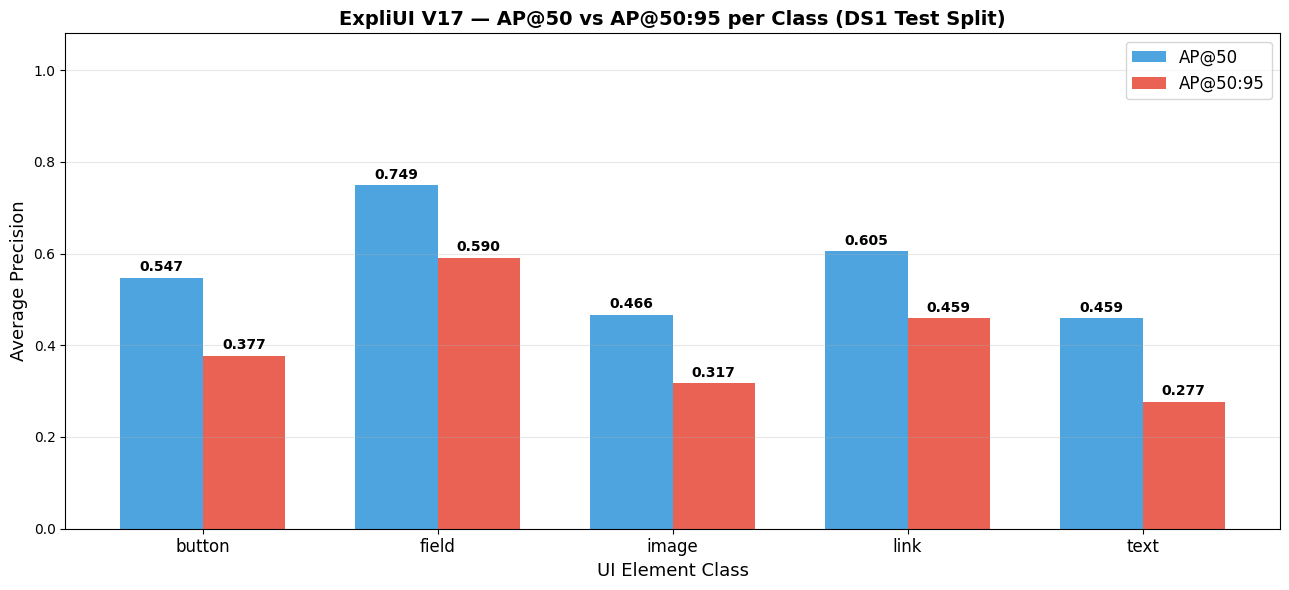

Saved: /content/ui_v17_eval_ds1/ds1_test_ap50_vs_ap5095.png


In [ ]:
CLASS_COLORS = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# Chart 1: AP@50 per class
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(TARGET_CLASSES, per_class_ap50,
              color=CLASS_COLORS, alpha=0.88, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, per_class_ap50):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(mAP50, color='#2c3e50', linestyle='--', linewidth=2,
           label=f'mAP@50 = {mAP50:.4f}')
ax.set_ylim(0, 1.08)
ax.set_xlabel('UI Element Class', fontsize=13)
ax.set_ylabel('AP @ IoU=0.50', fontsize=13)
ax.set_title('ExpliUI V17 — Per-Class AP@50 on DS1 Test Split',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path = os.path.join(EVAL_OUT, 'ds1_test_per_class_ap50.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', chart_path)

# Chart 2: AP@50:95 per class
fig, ax = plt.subplots(figsize=(12, 6))
bars2 = ax.bar(TARGET_CLASSES, per_class_ap5095,
               color=CLASS_COLORS, alpha=0.88, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars2, per_class_ap5095):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(mAP5095, color='#2c3e50', linestyle='--', linewidth=2,
           label=f'mAP@50:95 = {mAP5095:.4f}')
ax.set_ylim(0, 1.08)
ax.set_xlabel('UI Element Class', fontsize=13)
ax.set_ylabel('AP @ IoU=0.50:0.95', fontsize=13)
ax.set_title('ExpliUI V17 — Per-Class AP@50:95 on DS1 Test Split',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path2 = os.path.join(EVAL_OUT, 'ds1_test_per_class_ap5095.png')
plt.savefig(chart_path2, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', chart_path2)

# Chart 3: AP@50 vs AP@50:95 grouped comparison
x = np.arange(len(TARGET_CLASSES))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, per_class_ap50,   w, label='AP@50',    color='#3498db', alpha=0.88)
b2 = ax.bar(x + w/2, per_class_ap5095, w, label='AP@50:95', color='#e74c3c', alpha=0.88)
for bar, val in zip(b1, per_class_ap50):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(b2, per_class_ap5095):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(TARGET_CLASSES, fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_xlabel('UI Element Class', fontsize=13)
ax.set_ylabel('Average Precision', fontsize=13)
ax.set_title('ExpliUI V17 — AP@50 vs AP@50:95 per Class (DS1 Test Split)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
chart_path3 = os.path.join(EVAL_OUT, 'ds1_test_ap50_vs_ap5095.png')
plt.savefig(chart_path3, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', chart_path3)


## Step 8: Precision / Recall / F1 Per-Class Chart

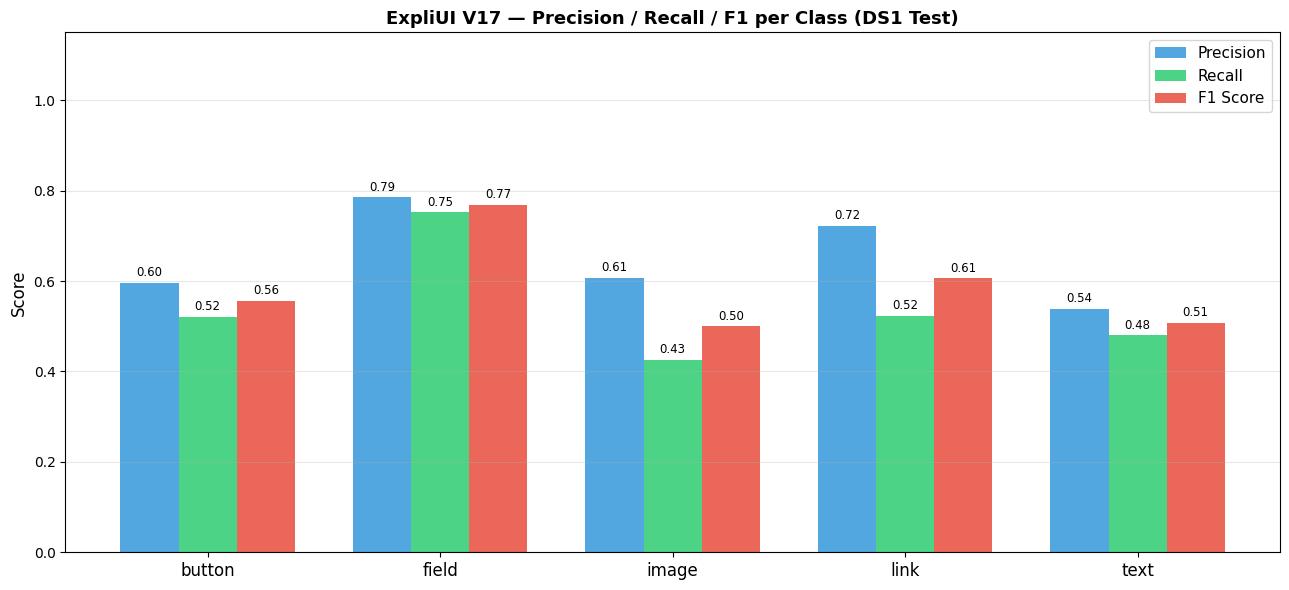

Saved: /content/ui_v17_eval_ds1/ds1_test_prf_per_class.png


In [ ]:
if per_class_p[0] is not None:
    x   = np.arange(len(TARGET_CLASSES))
    w   = 0.25
    f1s = [2*p*r/(p+r+1e-9) for p, r in zip(per_class_p, per_class_r)]

    fig, ax = plt.subplots(figsize=(13, 6))
    b1 = ax.bar(x - w, per_class_p, w, label='Precision', color='#3498db', alpha=0.85)
    b2 = ax.bar(x,     per_class_r, w, label='Recall',    color='#2ecc71', alpha=0.85)
    b3 = ax.bar(x + w, f1s,         w, label='F1 Score',  color='#e74c3c', alpha=0.85)

    for bars in [b1, b2, b3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.008,
                    f'{bar.get_height():.2f}',
                    ha='center', va='bottom', fontsize=8.5)

    ax.set_xticks(x)
    ax.set_xticklabels(TARGET_CLASSES, fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('ExpliUI V17 — Precision / Recall / F1 per Class (DS1 Test)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    prf_path = os.path.join(EVAL_OUT, 'ds1_test_prf_per_class.png')
    plt.savefig(prf_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved:', prf_path)
else:
    print('Per-class P/R not available from this YOLO val output — skip chart.')

## Step 9: Display Auto-Generated Plots (Confusion Matrix, PR Curve)

Found 2 auto-generated plots


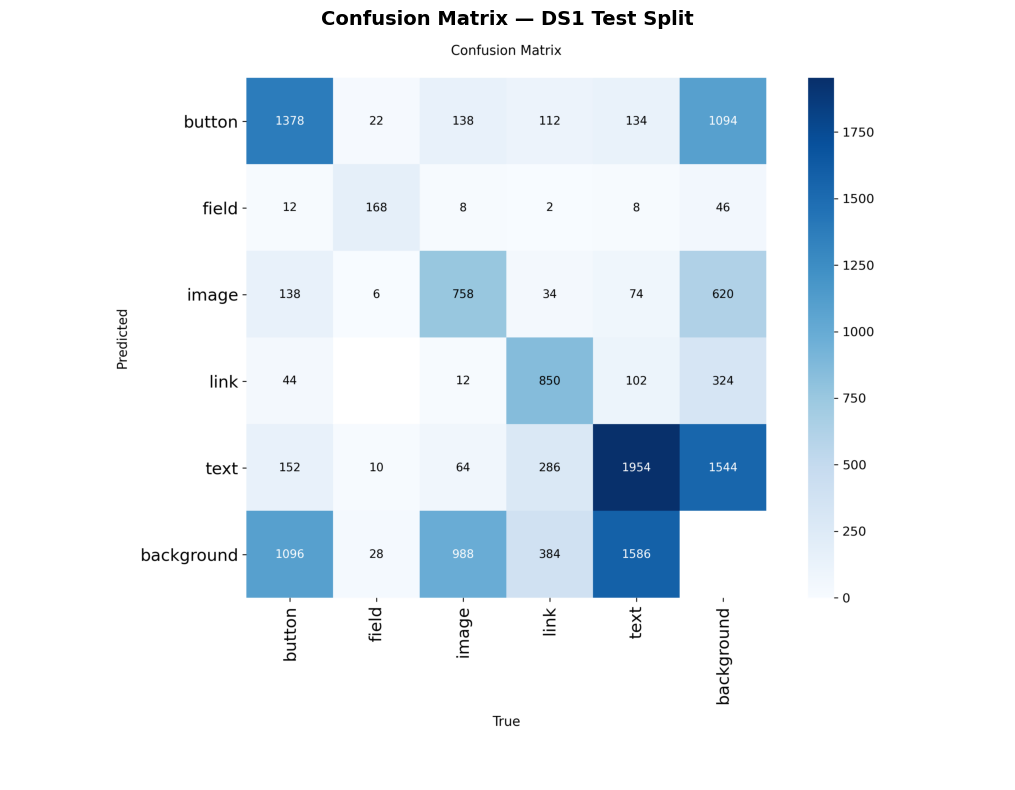

  Displayed: Confusion Matrix (/content/ui_v17_eval_ds1/confusion_matrix.png)


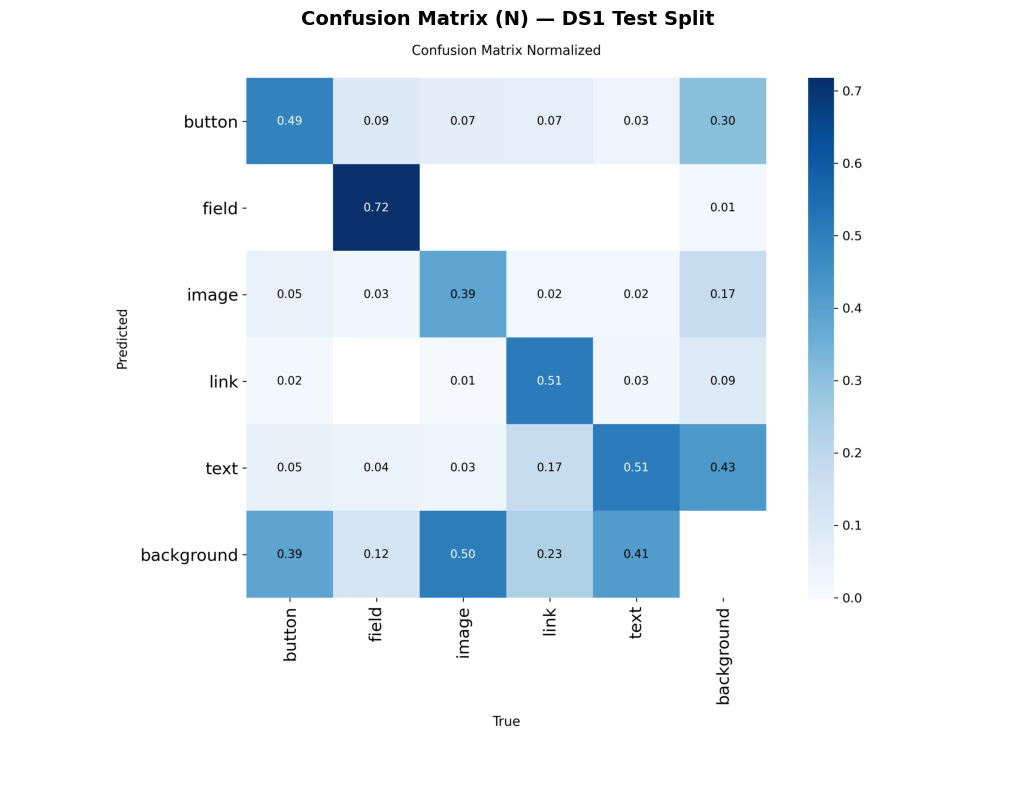

  Displayed: Confusion Matrix (N) (/content/ui_v17_eval_ds1/confusion_matrix_normalized.png)


In [ ]:
# YOLO auto-generates these in EVAL_OUT when plots=True
plot_files = {
    'Confusion Matrix'     : 'confusion_matrix.png',
    'Confusion Matrix (N)' : 'confusion_matrix_normalized.png',
    'PR Curve'             : 'PR_curve.png',
    'F1 Curve'             : 'F1_curve.png',
    'Precision Curve'      : 'P_curve.png',
    'Recall Curve'         : 'R_curve.png',
}

found_plots = {}
for name, fname in plot_files.items():
    path = os.path.join(EVAL_OUT, fname)
    if os.path.exists(path):
        found_plots[name] = path
    else:
        # Also check subdirs YOLO might create
        candidates = glob.glob(os.path.join(EVAL_OUT, '**', fname), recursive=True)
        if candidates:
            found_plots[name] = candidates[0]

print(f'Found {len(found_plots)} auto-generated plots')

# Display each found plot
from PIL import Image as PILImage

for name, path in found_plots.items():
    img = PILImage.open(path)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'{name} — DS1 Test Split', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'  Displayed: {name} ({path})')

## Step 10: Save All Results to Google Drive

In [ ]:
DRIVE_EVAL_SAVE = os.path.join(DRIVE_SAVE, 'eval_ds1_testonly')
os.makedirs(DRIVE_EVAL_SAVE, exist_ok=True)

print('Saving all results to Drive...')
print('=' * 55)

# Save all files from EVAL_OUT
for root, dirs, files in os.walk(EVAL_OUT):
    for fname in files:
        src = os.path.join(root, fname)
        dst = os.path.join(DRIVE_EVAL_SAVE, fname)
        shutil.copy(src, dst)
        print(f'  Saved: {fname}')

print()
print(f'All results saved to: {DRIVE_EVAL_SAVE}')
print()
print('Files saved:')
for fn in sorted(os.listdir(DRIVE_EVAL_SAVE)):
    print(f'  {fn}')

Saving all results to Drive...
  Saved: BoxP_curve.png
  Saved: ds1_test_ap50_vs_ap5095.png
  Saved: val_batch0_pred.jpg
  Saved: val_batch1_labels.jpg
  Saved: BoxR_curve.png
  Saved: ds1_test_results.csv
  Saved: val_batch1_pred.jpg
  Saved: ds1_test_prf_per_class.png
  Saved: BoxPR_curve.png
  Saved: ds1_test_per_class_ap50.png
  Saved: BoxF1_curve.png
  Saved: confusion_matrix.png
  Saved: val_batch2_pred.jpg
  Saved: val_batch2_labels.jpg
  Saved: ds1_test_per_class_ap5095.png
  Saved: confusion_matrix_normalized.png
  Saved: val_batch0_labels.jpg

All results saved to: /content/drive/MyDrive/DatasetNewV17/trained_models/eval_ds1_testonly

Files saved:
  BoxF1_curve.png
  BoxPR_curve.png
  BoxP_curve.png
  BoxR_curve.png
  confusion_matrix.png
  confusion_matrix_normalized.png
  ds1_test_ap50_vs_ap5095.png
  ds1_test_per_class_ap.png
  ds1_test_per_class_ap50.png
  ds1_test_per_class_ap5095.png
  ds1_test_prf_per_class.png
  ds1_test_results.csv
  val_batch0_labels.jpg
  val_batch